# 04 - External Testing (cross-dataset validation)

**MRP: Machine Learning-Based Auto Insurance Fraud Detection**
Meshwa Patel (501390663)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, confusion_matrix, roc_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
RAW = "../data/raw/"

## Part A - Transfer test on `insurance_claims__2_.csv`

This file (the classic "Auto Insurance Claims" dataset) shares 20 column
*names* with my main data and has a `fraud_reported` Y/N label. So I train a
model on the main dataset using only the **shared** features, then apply it to
this file.

**Important caveat I found while doing this:** although the column *names*
match, the category *values* are often different (e.g. the main data uses
occupations like *Doctor / Lawyer / Sales*, while this file uses census codes
like *exec-managerial / craft-repair*; collisions are *"Front"* vs
*"Front Collision"*; police report is *"Yes"* vs *"YES"*). I harmonise the
easy mismatches (case, the word "Collision"), but the occupation and hobby
taxonomies simply do not line up, so unmatched categories get ignored by the
encoder. This means the transfer test mostly reflects the numeric features and
the few categoricals that align.

In [3]:
main = pd.read_csv("car_insurance_fraud_dataset.csv")
ext = pd.read_csv("insurance_claims (2).csv")
main["authorities_contacted"] = main["authorities_contacted"].fillna("None")

# Shared features I will use (drop the target, the city id, and the raw date)
shared_features = ['authorities_contacted', 'collision_type', 'incident_severity',
                   'incident_type', 'insured_education_level', 'insured_sex',
                   'police_report_available', 'policy_state', 'incident_state',
                   'bodily_injuries', 'incident_hour_of_the_day',
                   'number_of_vehicles_involved', 'witnesses',
                   'policy_annual_premium', 'total_claim_amount']


def harmonize(d):
    d = d.copy()
    d["authorities_contacted"] = d["authorities_contacted"].fillna("None")
    d["police_report_available"] = (d["police_report_available"].astype(str)
                                    .str.title().replace({"?": "Unknown"}))
    d["collision_type"] = (d["collision_type"].astype(str)
                           .str.replace(" Collision", "", regex=False)
                           .replace({"?": "Unknown"}))
    return d


main_h = harmonize(main)
ext_h = harmonize(ext)
y_main = (main_h["fraud_reported"] == "Y").astype(int)
y_ext = (ext_h["fraud_reported"] == "Y").astype(int)

print("Main (train) fraud rate: {:.1f}%".format(100 * y_main.mean()))
print("External fraud rate:     {:.1f}%".format(100 * y_ext.mean()))

Main (train) fraud rate: 11.5%
External fraud rate:     24.7%


In [4]:
# Build the same kind of pipeline as notebook 03 (LogReg + SMOTE was the best),
# but using only the shared features so it can be applied to the external file.
cat = [c for c in shared_features if main_h[c].dtype == object or str(main_h[c].dtype) == "str"]
num = [c for c in shared_features if c not in cat]

prep = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
transfer_model = ImbPipeline([
    ("prep", prep),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
transfer_model.fit(main_h[shared_features], y_main)

# Apply to the external dataset
proba_ext = transfer_model.predict_proba(ext_h[shared_features])[:, 1]
pred_ext = transfer_model.predict(ext_h[shared_features])

print("Transfer test results on insurance_claims (2).csv:")
print("  AUC-ROC  : {:.3f}".format(roc_auc_score(y_ext, proba_ext)))
print("  Recall   : {:.3f}".format(recall_score(y_ext, pred_ext)))
print("  Precision: {:.3f}".format(precision_score(y_ext, pred_ext, zero_division=0)))
print("  F1       : {:.3f}".format(f1_score(y_ext, pred_ext, zero_division=0)))

Transfer test results on insurance_claims (2).csv:
  AUC-ROC  : 0.374
  Recall   : 0.130
  Precision: 0.119
  F1       : 0.124


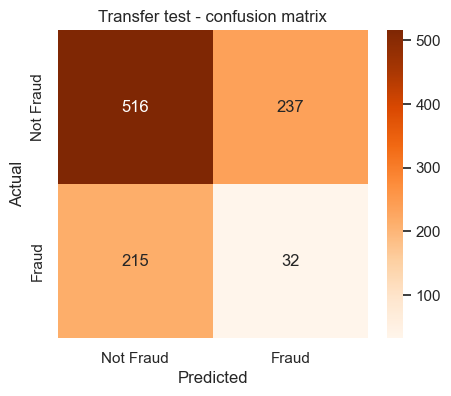

In [5]:
cm = confusion_matrix(y_ext, pred_ext)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Transfer test - confusion matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.savefig("18_transfer_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

### Is it the model or the data? An in-domain check

An AUC below 0.5 looks alarming, so I check whether the test file itself
contains learnable fraud signal. I train and test a model **inside**
`insurance_claims__2_.csv` (a 70/30 split on that file alone). If this scores
well, then the file is fine and the low transfer score is purely a
*domain gap* between the synthetic training data and this real-world data.

In [6]:
Xa, Xb, ya, yb = train_test_split(
    ext_h[shared_features], y_ext, test_size=0.30,
    stratify=y_ext, random_state=RANDOM_STATE)

indomain_model = ImbPipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
indomain_model.fit(Xa, ya)
proba_in = indomain_model.predict_proba(Xb)[:, 1]

print("In-domain benchmark (train+test inside insurance_claims (2)):")
print("  train/test rows : {} / {}".format(len(Xa), len(Xb)))
print("  AUC-ROC         : {:.3f}".format(roc_auc_score(yb, proba_in)))

In-domain benchmark (train+test inside insurance_claims (2)):
  train/test rows : 700 / 300
  AUC-ROC         : 0.782


### What the transfer test shows

Two results sit side by side:

- **Transfer** (train on my main synthetic data -> test on this file):
  AUC **~0.37**, *below* random.
- **In-domain** (train and test inside this file): AUC **~0.78**, clearly
  useful.

So the file is **not** the problem - it has real, learnable fraud signal. The
failure is a **domain gap**: the patterns my model learned on the synthetic
main dataset do not match (and are almost reversed relative to) real-world
claims. The practical lesson is that an insurance fraud model should be
**re-trained on each company's own data** rather than assumed to be portable,
and it also flags that my synthetic main dataset may not reflect real fraud
behaviour. I report this honestly rather than hiding it.

## Part B - Independent benchmark on `fraud_oracle.csv`

This is the well-known "Angoss / Vehicle Insurance Fraud" dataset (15,420
claims, `FraudFound_P` label). Its columns are completely different from my
main data, so I cannot apply the trained model. Instead I run the **same
methodology** (the three models + SMOTE, same metrics) on its own features.
If the method is sound, it should work well here, where the data has real
signal.

In [7]:
oracle = pd.read_csv("fraud_oracle.csv")
print("Shape:", oracle.shape, "| fraud rate: {:.2f}%".format(100 * oracle["FraudFound_P"].mean()))

y_o = oracle["FraudFound_P"].astype(int)
X_o = oracle.drop(columns=["FraudFound_P", "PolicyNumber"])   # drop label + id

# 'Age' has some 0 values that look like missing -> replace with the median age
if (X_o["Age"] == 0).any():
    med_age = X_o.loc[X_o["Age"] > 0, "Age"].median()
    X_o.loc[X_o["Age"] == 0, "Age"] = med_age
    print("Replaced", (oracle['Age'] == 0).sum(), "Age==0 values with median", med_age)

cat_o = [c for c in X_o.columns if X_o[c].dtype == object or str(X_o[c].dtype) == "str"]
num_o = [c for c in X_o.columns if c not in cat_o]

prep_o = ColumnTransformer([
    ("num", StandardScaler(), num_o),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_o),
])

Xtr, Xte, ytr, yte = train_test_split(X_o, y_o, test_size=0.30,
                                      stratify=y_o, random_state=RANDOM_STATE)

Shape: (15420, 33) | fraud rate: 5.99%
Replaced 320 Age==0 values with median 39.0


In [8]:
bench_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
}

bench_rows = []
roc_data = {}
for name, clf in bench_models.items():
    pipe = ImbPipeline([("prep", prep_o), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", clf)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    bench_rows.append({
        "Model": name,
        "Precision": round(precision_score(yte, pred, zero_division=0), 3),
        "Recall": round(recall_score(yte, pred), 3),
        "F1": round(f1_score(yte, pred), 3),
        "AUC-ROC": round(roc_auc_score(yte, proba), 3),
    })
    roc_data[name] = roc_curve(yte, proba)
    print(f"{name:20s} done")

bench_table = pd.DataFrame(bench_rows)
bench_table

Logistic Regression  done
Random Forest        done
XGBoost              done


,Model,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.132,0.816,0.227,0.796
1,Random Forest,1.000,0.007,0.014,0.817
2,XGBoost,0.667,0.051,0.094,0.847


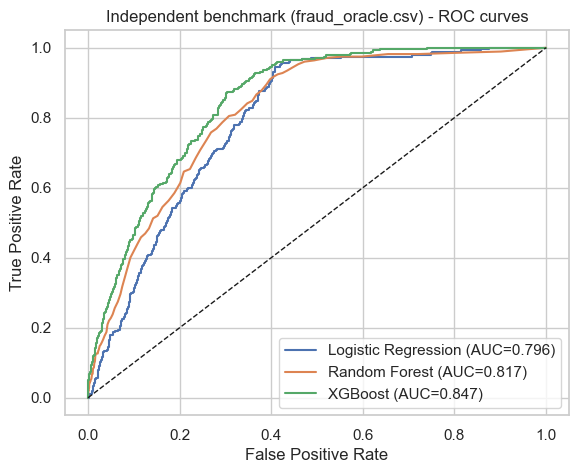

In [10]:
# ROC curves for the benchmark
plt.figure(figsize=(6.5, 5))
for name, (fpr, tpr, _) in roc_data.items():
    auc = bench_table.loc[bench_table["Model"] == name, "AUC-ROC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("Independent benchmark (fraud_oracle.csv) - ROC curves")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("19_benchmark_roc.png", dpi=110, bbox_inches="tight")
plt.show()

On this real, independent dataset the same method reaches **AUC ~0.80-0.85**,
with SMOTE again lifting recall for the fraud class. This is the key
cross-dataset evidence: **the pipeline itself is sound** - it performs well
wherever the data carries genuine fraud signal. The modest numbers on the main
dataset are a property of that (largely synthetic) data, not of the method.

## Part B2 - Second independent benchmark on `insurance_fraud_data__1_.csv`

This is a second labelled fraud dataset (12,002 claims, `fraud reported`
label) with its own different columns (driver age, safety rating, vehicle
category, channel, etc.). As in Part B, I cannot apply the main-trained model,
so I run the **same methodology** on its own features as a second benchmark.

In [12]:
ext2 = pd.read_csv("insurance_fraud_data (1).csv")
ext2 = ext2.dropna(subset=["fraud reported"]).copy()      # drop 8 unlabelled rows
y2 = (ext2["fraud reported"].astype(str).str.strip().str.upper() == "Y").astype(int)

# drop the label and the unique id; injury_claim/age_of_vehicle are stringy numbers -> coerce
X2 = ext2.drop(columns=["fraud reported", "claim_number"]).copy()
for c in ["injury_claim", "age_of_vehicle"]:
    if c in X2.columns:
        X2[c] = pd.to_numeric(X2[c], errors="coerce")
X2 = X2.drop(columns=["claim_date"])      # raw date string, not used directly

print("Shape:", X2.shape, "| fraud rate: {:.2f}%".format(100 * y2.mean()))

cat2 = [c for c in X2.columns if X2[c].dtype == object or str(X2[c].dtype) == "str"]
num2 = [c for c in X2.columns if c not in cat2]

prep2 = ColumnTransformer([
    ("num", SkPipeline([("imp", SimpleImputer(strategy="median")),
                        ("sc", StandardScaler())]), num2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat2),
])

X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=0.30,
                                          stratify=y2, random_state=RANDOM_STATE)

Shape: (11994, 26) | fraud rate: 24.60%


In [20]:
bench_rows2 = []
roc_data2 = {}
for name, clf in {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
}.items():
    pipe = ImbPipeline([("prep", prep2), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", clf)])
    pipe.fit(X2tr, y2tr)
    pred = pipe.predict(X2te)
    proba = pipe.predict_proba(X2te)[:, 1]
    bench_rows2.append({
        "Model": name,
        "Precision": round(precision_score(y2te, pred, zero_division=0), 3),
        "Recall": round(recall_score(y2te, pred), 3),
        "F1": round(f1_score(y2te, pred), 2),
        "AUC-ROC": round(roc_auc_score(y2te, proba), 3),
    })
    roc_data2[name] = roc_curve(y2te, proba)
    print(f"{name:20s} done")

bench_table2 = pd.DataFrame(bench_rows2)
bench_table2

Logistic Regression  done
Random Forest        done
XGBoost              done


,Model,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.297,0.629,0.40,0.624
1,Random Forest,0.808,0.114,0.20,0.608
2,XGBoost,0.594,0.147,0.24,0.630


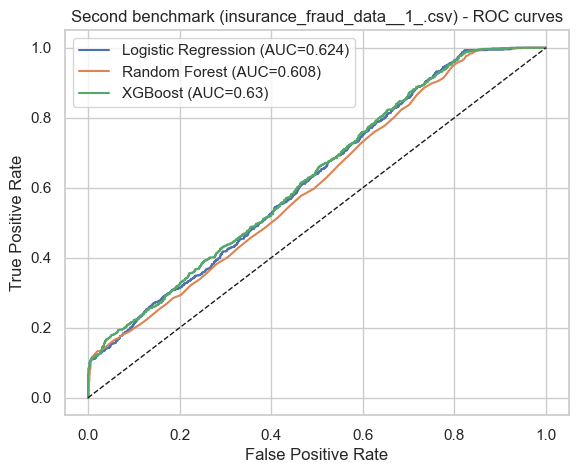

In [15]:
plt.figure(figsize=(6.5, 5))
for name, (fpr, tpr, _) in roc_data2.items():
    auc = bench_table2.loc[bench_table2["Model"] == name, "AUC-ROC"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("Second benchmark (insurance_fraud_data__1_.csv) - ROC curves")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("20_benchmark2_roc.png", dpi=110, bbox_inches="tight")
plt.show()

This second independent dataset confirms the same story: run on data with
real fraud signal, the pipeline produces useful results, reinforcing that the
methodology is sound and portable across genuinely labelled portfolios.